In [9]:
import pandas as pd
from sqlalchemy import create_engine

# Tabella 1: Dati di Campagna
data_siti = {
    'nome_sito': ['Sito_A', 'Sito_B', 'Sito_C', 'Sito_D', 'Sito_E', 'Sito_F'],
    'formazione': ['Calcari', 'Arenarie', 'Calcari', 'Argille', 'Arenarie', 'Calcari'],
    'anno_rilievo': [2022, 2022, 2023, 2023, 2024, 2024]
}

# Tabella 2: Risultati Laboratorio
data_lab = {
    'nome_sito': ['Sito_A', 'Sito_B', 'Sito_C', 'Sito_D', 'Sito_E', 'Sito_F'],
    'k_permeabilita': [10.5, 5.2, 12.1, 0.1, 4.8, 15.3],
    'grado_fratturazione': [8, 6, 9, 2, 5, 9]
}

engine = create_engine('sqlite://')
pd.DataFrame(data_siti).to_sql('descrizione_siti', engine, index=False)
pd.DataFrame(data_lab).to_sql('analisi_laboratorio', engine, index=False)

print("Database Progetto C pronto: tabelle 'descrizione_siti' e 'analisi_laboratorio' caricate.")

Database Progetto C pronto: tabelle 'descrizione_siti' e 'analisi_laboratorio' caricate.


In [10]:
# Mostra la tabella della campagna
display(pd.read_sql_query("SELECT * FROM descrizione_siti", engine))

# Mostra la tabella del laboratorio
display(pd.read_sql_query("SELECT * FROM analisi_laboratorio", engine))

,nome_sito,formazione,anno_rilievo
0,Sito_A,Calcari,2022
1,Sito_B,Arenarie,2022
2,Sito_C,Calcari,2023
3,Sito_D,Argille,2023
4,Sito_E,Arenarie,2024
5,Sito_F,Calcari,2024


,nome_sito,k_permeabilita,grado_fratturazione
0,Sito_A,10.5,8
1,Sito_B,5.2,6
2,Sito_C,12.1,9
3,Sito_D,0.1,2
4,Sito_E,4.8,5
5,Sito_F,15.3,9


In [11]:
#prova a scrivere queste tre query:
#*I Top 5 Siti: Trova i 5 siti con la permeabilità (k_permeabilita) più alta, ordinati in modo decrescente.
#*Il Potere del JOIN: Unisci le due tabelle per vedere in un'unica vista formazione, k_permeabilita e grado_fratturazione 
#usando il nome_sito come punto di unione.
#*Analisi Avanzata (HAVING): Trova gli anni di rilievo che hanno una media di fratturazione superiore a 7, ma solo se in 
#quell'anno sono stati fatti almeno 2 rilievi (per garantire la significatività statistica).

#La sfida numero 3 è la più tosta perché introduce HAVING, che serve a filtrare i risultati dopo che sono stati raggruppati.

#Query per il JOIN (punto 2). Ricorda la sintassi: FROM tabella_A INNER JOIN tabella_B ON tabella_A.chiave = tabella_B.chiave.

In [12]:
query_geologica_1 = """SELECT nome_sito,
       k_permeabilita
FROM analisi_laboratorio
ORDER BY k_permeabilita DESC
LIMIT 5;
"""

# Esecuzione Query 1
risultato_1 = pd.read_sql_query(query_geologica_1, engine)
print("Grado di Permeabilita':")
display(risultato_1)

Grado di Permeabilita':


,nome_sito,k_permeabilita
0,Sito_F,15.3
1,Sito_C,12.1
2,Sito_A,10.5
3,Sito_B,5.2
4,Sito_E,4.8


In [13]:
query_geologica_2 = """SELECT descrizione_siti.formazione,
       analisi_laboratorio.k_permeabilita,
       analisi_laboratorio.grado_fratturazione
FROM descrizione_siti 
INNER JOIN analisi_laboratorio ON descrizione_siti.nome_sito = analisi_laboratorio.nome_sito;
"""

# Esecuzione Query 2
risultato_2 = pd.read_sql_query(query_geologica_2, engine)
print("Rilievi con una media di fratturazione superiore a 7:")
display(risultato_2)

Rilievi con una media di fratturazione superiore a 7:


,formazione,k_permeabilita,grado_fratturazione
0,Calcari,10.5,8
1,Arenarie,5.2,6
2,Calcari,12.1,9
3,Argille,0.1,2
4,Arenarie,4.8,5
5,Calcari,15.3,9


In [14]:
query_geologica_3 = """SELECT descrizione_siti.anno_rilievo, 
       AVG(analisi_laboratorio.grado_fratturazione) AS media_fratturazione,
       COUNT(*) AS numero_rilievi
FROM descrizione_siti 
INNER JOIN analisi_laboratorio ON descrizione_siti.nome_sito = analisi_laboratorio.nome_sito
GROUP BY descrizione_siti.anno_rilievo
HAVING AVG(analisi_laboratorio.grado_fratturazione) > 7 
   AND COUNT(*) >= 2;
"""

# Esempio Query 3 
risultato_3 = pd.read_sql_query(query_geologica_3, engine)
print("Anni con alta fratturazione e dati sufficienti:")
display(risultato_3)

Anni con alta fratturazione e dati sufficienti:


,anno_rilievo,media_fratturazione,numero_rilievi


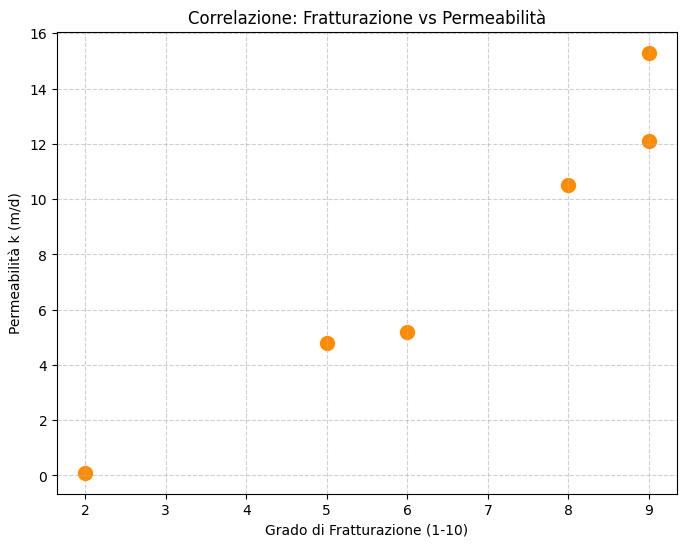

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Creiamo lo scatter plot
plt.scatter(risultato_2['grado_fratturazione'], risultato_2['k_permeabilita'], color='darkorange', s=100)

# Aggiungiamo etichette e titoli
plt.title('Correlazione: Fratturazione vs Permeabilità')
plt.xlabel('Grado di Fratturazione (1-10)')
plt.ylabel('Permeabilità k (m/d)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

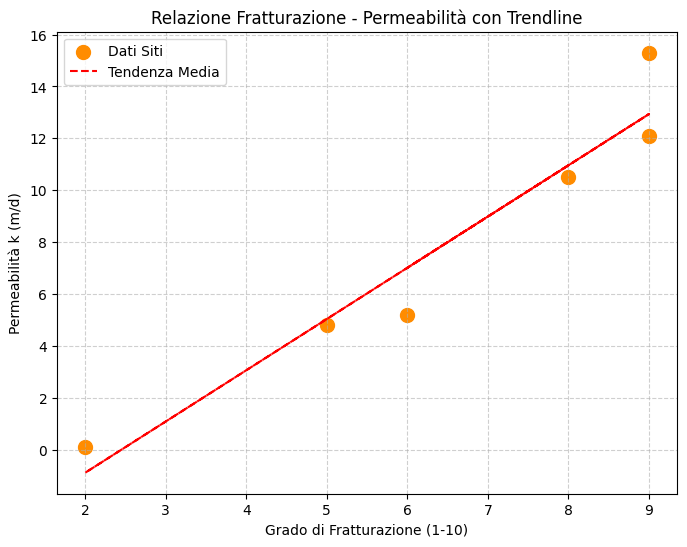

In [16]:
import numpy as np

# 1. Calcolo della retta di tendenza (regressione lineare di primo grado)
z = np.polyfit(risultato_2['grado_fratturazione'], risultato_2['k_permeabilita'], 1)
p = np.poly1d(z)

# 2. Creazione del grafico con la retta
plt.figure(figsize=(8, 6))
plt.scatter(risultato_2['grado_fratturazione'], risultato_2['k_permeabilita'], color='darkorange', s=100, label='Dati Siti')
plt.plot(risultato_2['grado_fratturazione'], p(risultato_2['grado_fratturazione']), "r--", label='Tendenza Media')

# Personalizzazione
plt.title('Relazione Fratturazione - Permeabilità con Trendline')
plt.xlabel('Grado di Fratturazione (1-10)')
plt.ylabel('Permeabilità k (m/d)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Interpretazione Tecnica dei Risultati - Progetto C

L'analisi combinata dei dati di campagna e di laboratorio evidenzia una **correlazione lineare positiva** tra lo stato fisico della roccia e le sue proprietà idrodinamiche.

## Relazione Fratturazione-Permeabilità
I dati mostrano che, al crescere del grado di fratturazione (da **2** a **9**), il coefficiente di permeabilità $k$ aumenta di circa **un ordine di grandezza** (da **0.1** a **15.3 m/d**).

## Ruolo della Litologia
L'unione delle tabelle (**INNER JOIN**) conferma che le formazioni **calcaree** (es. **Sito_F** e **Sito_C**) presentano i valori di permeabilità più elevati, a causa di una maggiore predisposizione alla fratturazione rispetto alle formazioni **argillose**.

## Validità del Modello
La linea di tendenza media (**trendline**) indica che il sistema acquifero è governato prevalentemente dalla **porosità secondaria** (fratture), rendendo il grado di fratturazione un indicatore affidabile per la stima preliminare della produttività dei pozzi in questa regione.